In [ ]:
# SETUP

import os
import sys

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from scipy import stats
import wandb

# Import notebook utilities
from src.utils.nb_utils import setup_notebook, load_transformer_model, load_sae

# Import project utilities
from src.utils.runtime import configure_runtime
from src.models.transformer import parse_model_name_safe, build_attention_mask
from src.models.utils import load_model
from src.data.datasets import get_dataset
from src.sae.sae_analysis import *

# Setup device and seeds
DEVICE = setup_notebook(seed=42)

# --- Configuration ---
MODEL_NAME = '2layer_100dig_64d'
# looking at:
SAE_NAME = "sae_d100_k3_lr0.0003_seed44_2layer_100dig_64d.pt" # MSE: 0.0042, Recon Acc: 0.8688 (old - not as high accuracy as below)
# SAE_NAME = "sae_d100_k3_lr0.0001_seed43_2layer_100dig_64d.pt" # MSE: 0.0036, Recon Acc: 0.8752
# SAE_NAME = "sae_d100_k4_50ksteps_2layer_100dig_64d.pt" # (classic - best recon accuracy of 0.8885) 


# Output Config
SAVE_RESULTS = False
SAVE_DIR = "../results/sae_results/" if SAVE_RESULTS else None

# --- Load Models ---
model, model_cfg = load_transformer_model(MODEL_NAME, device=DEVICE)

# Extract config for convenience
D_MODEL = model_cfg['d_model']
N_LAYERS = model_cfg['n_layers']
N_HEADS = model_cfg['n_heads']
LIST_LEN = model_cfg['list_len']
N_DIGITS = model_cfg['n_digits']
SEP_TOKEN_INDEX = model_cfg['sep_token_index']

# Load SAE
sae, sae_cfg = load_sae(SAE_NAME, D_MODEL, device=DEVICE)
D_SAE = sae_cfg['dict_size']
TOP_K = sae_cfg['k']

# Load activation mean from checkpoint (for centering)
SAE_PATH = os.path.join('../results/sae_models', SAE_NAME)
sae_checkpoint = torch.load(SAE_PATH, map_location=DEVICE, weights_only=False)
act_mean = sae_checkpoint["act_mean"].to(DEVICE)

/Users/Subspace_Explorer/Projects/list-comp-priv/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps
Parsed model config (old format): 2 layers, 100 digits, 64 d_model, list_len=2
Loading model from ../models/2layer_100dig_64d.pt
Moving model to device:  mps
✓ Loaded model from ../models/2layer_100dig_64d.pt
✓ Loaded SAE from ../results/sae_models/sae_d100_k3_lr0.0003_seed44_2layer_100dig_64d.pt
  - Dictionary size: 100
  - Top-K: 3


In [ ]:
# Load validation dataset and collect SAE activations
train_ds, val_ds = get_dataset(
    n_digits=N_DIGITS,
    list_len=LIST_LEN,
    no_dupes=False,
    train_dupes_only=False
)
# concat both
all_ds = torch.utils.data.ConcatDataset([train_ds, val_ds])

train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=128, shuffle=False)
all_dl = DataLoader(all_ds, batch_size=128, shuffle=False)

# Collect SAE activations for ALL data (not getting acccuracy so it's fine to incl train)
d1_all, d2_all, sae_acts_all = collect_sae_activations(
    model=model,
    sae=sae,
    val_dl=all_dl, 
    act_mean=act_mean,
    layer_idx=0,
    sep_idx=SEP_TOKEN_INDEX,
    device=DEVICE
)

In [ ]:
# get data for analysis

# Extract attention weights from SEP token to input positions
alpha_d1_all, alpha_d2_all = collect_attention_weights(
    model=model,
    dataloader=all_dl,
    sep_idx=SEP_TOKEN_INDEX,
    device=DEVICE
)

# Identify special features
special_features_info = identify_special_features(
    sae_acts_all=sae_acts_all,
    alpha_d1_all=alpha_d1_all,
    alpha_d2_all=alpha_d2_all,
    threshold=0.5
)

feature_firing_freq = (sae_acts_all > 0).float().mean(dim=0).numpy()
active_features = np.where(feature_firing_freq > 0)[0]
n_active = len(active_features)

# Sort by firing frequency
sorted_indices = np.argsort(feature_firing_freq)[::-1]
top_n = min(30, n_active)

Feature 30 fires on 7054 / 10000 inputs


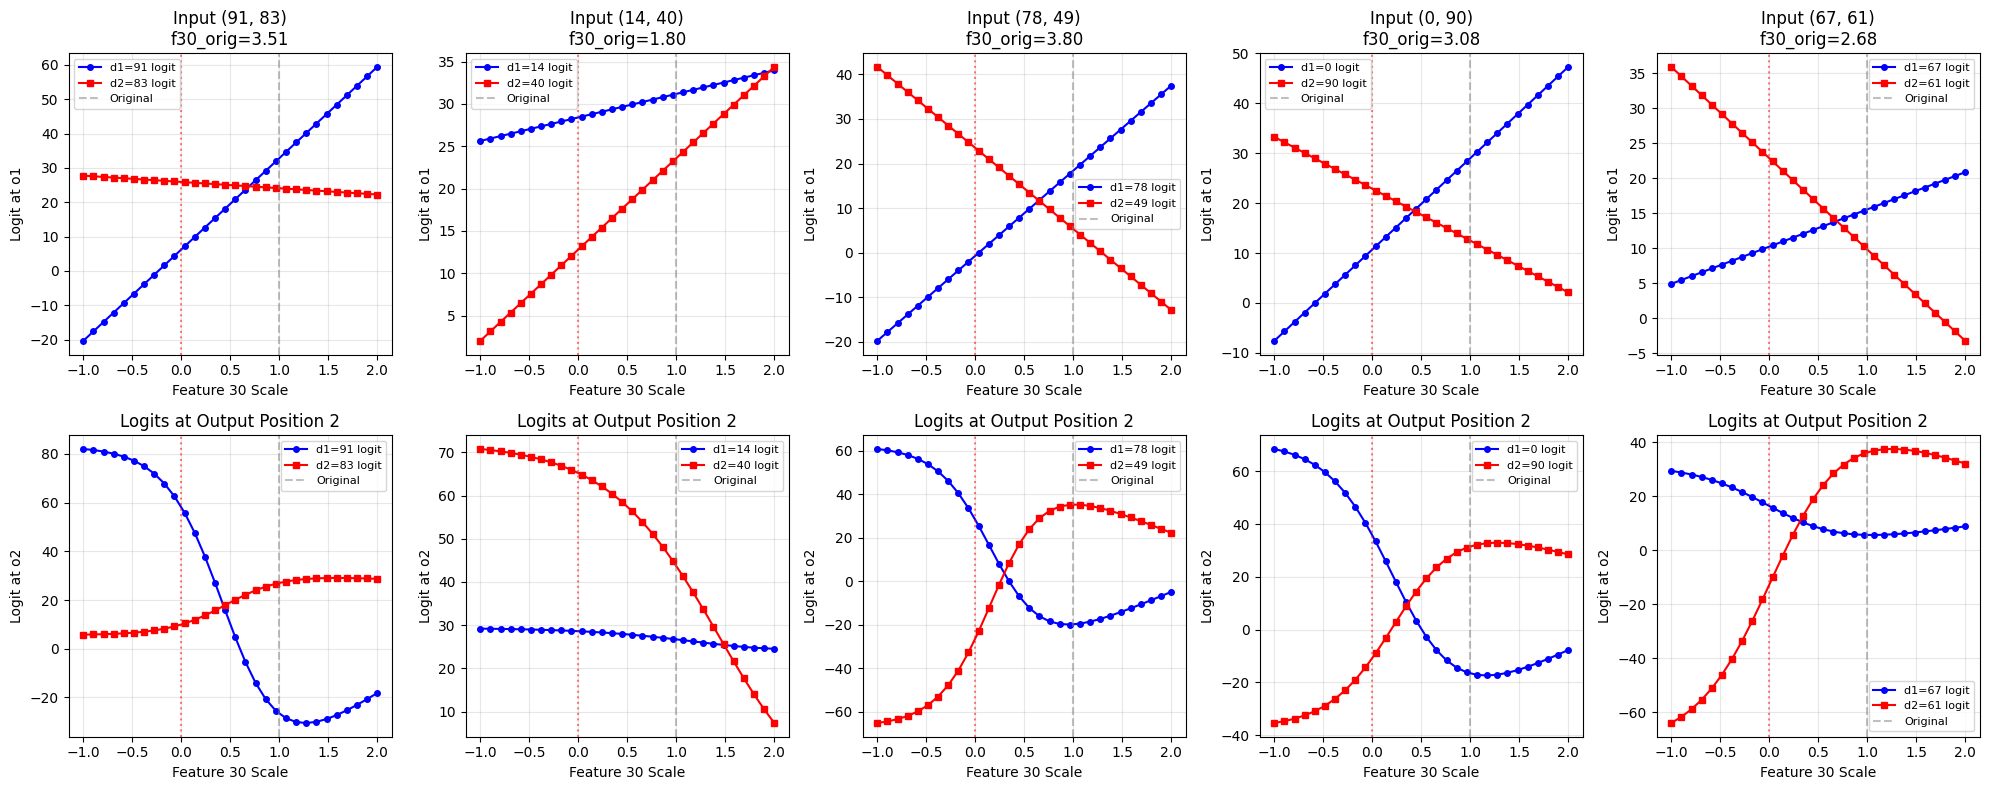

In [ ]:
SPECIAL_FEAT_IDX = 30

results = feature_steering_experiment(
    model=model, sae=sae, act_mean=act_mean,
    feature_idx=SPECIAL_FEAT_IDX,
    d1_all=d1_all, d2_all=d2_all, sae_acts_all=sae_acts_all,
    dataset=all_ds,
    sep_idx=SEP_TOKEN_INDEX,
    n_digits=N_DIGITS,
    plot=True,
    save_dir=SAVE_DIR
)

 the above graph just shows 5 random input examples

 TODO
 1) need to check all other logits - it may look good here but maybe another logit overtakes
 2) try 'non-special' features - does the same pattern appear (yes) ==> why is special one 'special'? have i just found a vis to fit my hopes?
 3) try actually steering with it --> should be able to predict that we can boost/damp f30 by x% and swap the ouputs logits ==> (maybe) we've got a feature that controls output order

 GOAL - show that this feature reliably swaps outputs (or it doesnt!)


Found input (91, 83) at index 7534
Original feature 30 activation: 3.5068


Testing scales: 100%|██████████| 30/30 [00:00<00:00, 333.24it/s]


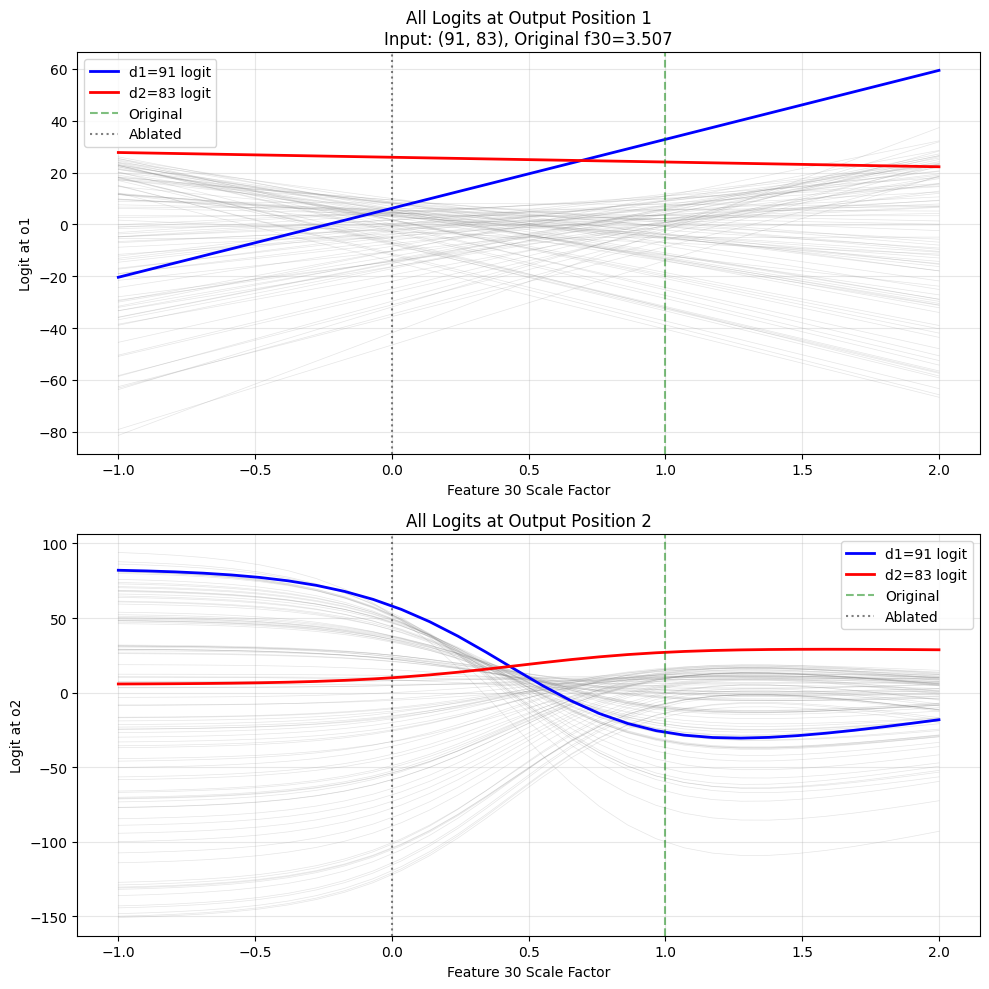


CROSSOVER ANALYSIS

📍 O1 Logits cross over at scale ≈ 0.655
   At this point: d1 logit = 23.670, d2 logit = 24.733

📍 O2 Logits cross over at scale ≈ 0.345
   At this point: d1 logit = 27.062, d2 logit = 15.700


In [ ]:
# let's focus on the logits for a particular input example (91, 83).
# plot red line for d2=83 logit, blue line for d1=91 logit, and grey lines for all other logits
# ==> should be 100 lines in total!

# Find index for example input
d1_val, d2_val = 91, 83
mask = (d1_all == d1_val) & (d2_all == d2_val)
if mask.sum() == 0:
    print(f"Input ({d1_val}, {d2_val}) not found in dataset!")
else:
    input_idx = torch.where(mask)[0][0].item()
    print(f"Found input ({d1_val}, {d2_val}) at index {input_idx}")
    
    # Get the input and original SAE activations
    inputs_i = all_ds[input_idx][0].unsqueeze(0).to(DEVICE)
    z_orig = sae_acts_all[input_idx].clone().to(DEVICE)
    feat_orig = z_orig[SPECIAL_FEAT_IDX].item()
    
    print(f"Original feature {SPECIAL_FEAT_IDX} activation: {feat_orig:.4f}")
    
    # Test scale factors from -1 to 2
    scale_factors = np.linspace(-1.0, 2.0, 30)
    
    # Storage for all logits at o1 and o2
    all_logits_o1 = []  # Will be shape [n_scales, n_digits]
    all_logits_o2 = []  # Will be shape [n_scales, n_digits]
    
    hook_name_resid = f"blocks.0.hook_resid_post"
    
    for scale in tqdm(scale_factors, desc="Testing scales"):
        z_scaled = z_orig.clone()
        z_scaled[SPECIAL_FEAT_IDX] = feat_orig * scale
        
        recon = sae.decode(z_scaled.unsqueeze(0))
        
        with torch.no_grad():
            patched_logits = model.run_with_hooks(
                inputs_i,
                fwd_hooks=[(hook_name_resid, make_sae_patch_hook(recon, act_mean, SEP_TOKEN_INDEX))]
            )
        
        # Get logits at o1 (position -2) and o2 (position -1) for ALL digits
        logits_o1 = patched_logits[0, -2, :N_DIGITS].cpu().numpy()
        logits_o2 = patched_logits[0, -1, :N_DIGITS].cpu().numpy()
        all_logits_o1.append(logits_o1)
        all_logits_o2.append(logits_o2)
    
    all_logits_o1 = np.array(all_logits_o1)  # [n_scales, n_digits]
    all_logits_o2 = np.array(all_logits_o2)  # [n_scales, n_digits]
    
    # Create 2-row plot
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))
    
    # Plot o1 logits (top row)
    ax1 = axes[0]
    
    # Plot all other logits in grey
    for digit in range(N_DIGITS):
        if digit != d1_val and digit != d2_val:
            ax1.plot(scale_factors, all_logits_o1[:, digit], 'grey', alpha=0.2, linewidth=0.5)
    
    # Plot d1 and d2 logits on top
    ax1.plot(scale_factors, all_logits_o1[:, d1_val], 'b-', linewidth=2, label=f'd1={d1_val} logit')
    ax1.plot(scale_factors, all_logits_o1[:, d2_val], 'r-', linewidth=2, label=f'd2={d2_val} logit')
    
    # Mark original activation point
    ax1.axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='Original')
    ax1.axvline(x=0.0, color='black', linestyle=':', alpha=0.5, label='Ablated')
    
    ax1.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax1.set_ylabel('Logit at o1')
    ax1.set_title(f'All Logits at Output Position 1
Input: ({d1_val}, {d2_val}), Original f{SPECIAL_FEAT_IDX}={feat_orig:.3f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot o2 logits (bottom row)
    ax2 = axes[1]
    
    # Plot all other logits in grey
    for digit in range(N_DIGITS):
        if digit != d1_val and digit != d2_val:
            ax2.plot(scale_factors, all_logits_o2[:, digit], 'grey', alpha=0.2, linewidth=0.5)
    
    # Plot d1 and d2 logits on top
    ax2.plot(scale_factors, all_logits_o2[:, d1_val], 'b-', linewidth=2, label=f'd1={d1_val} logit')
    ax2.plot(scale_factors, all_logits_o2[:, d2_val], 'r-', linewidth=2, label=f'd2={d2_val} logit')
    
    # Mark original activation point
    ax2.axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='Original')
    ax2.axvline(x=0.0, color='black', linestyle=':', alpha=0.5, label='Ablated')
    
    ax2.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax2.set_ylabel('Logit at o2')
    ax2.set_title(f'All Logits at Output Position 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax2.set_ylabel('Logit at o2')
    ax2.set_title(f'All Logits at Output Position 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if SAVE_DIR:
        plt.savefig(os.path.join(SAVE_DIR, f'all_logits_o1_o2_f{SPECIAL_FEAT_IDX}_input_{d1_val}_{d2_val}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print crossover points for both positions
    d1_logits_o1 = all_logits_o1[:, d1_val]
    d2_logits_o1 = all_logits_o1[:, d2_val]
    diff_o1 = d1_logits_o1 - d2_logits_o1
    
    d1_logits_o2 = all_logits_o2[:, d1_val]
    d2_logits_o2 = all_logits_o2[:, d2_val]
    diff_o2 = d1_logits_o2 - d2_logits_o2
    
    print("
" + "="*60)
    print("CROSSOVER ANALYSIS")
    print("="*60)
    
    # Find where sign changes (crossover) for o1
    sign_changes_o1 = np.where(np.diff(np.sign(diff_o1)))[0]
    if len(sign_changes_o1) > 0:
        crossover_idx_o1 = sign_changes_o1[0]
        crossover_scale_o1 = scale_factors[crossover_idx_o1]
        print(f"
📍 O1 Logits cross over at scale ≈ {crossover_scale_o1:.3f}")
        print(f"   At this point: d1 logit = {d1_logits_o1[crossover_idx_o1]:.3f}, d2 logit = {d2_logits_o1[crossover_idx_o1]:.3f}")
    else:
        print(f"
❌ O1: No crossover detected in range [{scale_factors[0]:.1f}, {scale_factors[-1]:.1f}]")
        if d1_logits_o1[0] > d2_logits_o1[0]:
            print("   d1 logit remains higher throughout")
        else:
            print("   d2 logit remains higher throughout")
    
    # Find where sign changes (crossover) for o2
    sign_changes_o2 = np.where(np.diff(np.sign(diff_o2)))[0]
    if len(sign_changes_o2) > 0:
        crossover_idx_o2 = sign_changes_o2[0]
        crossover_scale_o2 = scale_factors[crossover_idx_o2]
        print(f"
📍 O2 Logits cross over at scale ≈ {crossover_scale_o2:.3f}")
        print(f"   At this point: d1 logit = {d1_logits_o2[crossover_idx_o2]:.3f}, d2 logit = {d2_logits_o2[crossover_idx_o2]:.3f}")
    else:
        print(f"
❌ O2: No crossover detected in range [{scale_factors[0]:.1f}, {scale_factors[-1]:.1f}]")
        if d1_logits_o2[0] > d2_logits_o2[0]:
            print("   d1 logit remains higher throughout")
        else:
            print("   d2 logit remains higher throughout")

Found input (0, 90) at index 6411
Original feature 30 activation: 3.0842


Testing scales: 100%|██████████| 30/30 [00:00<00:00, 276.64it/s]


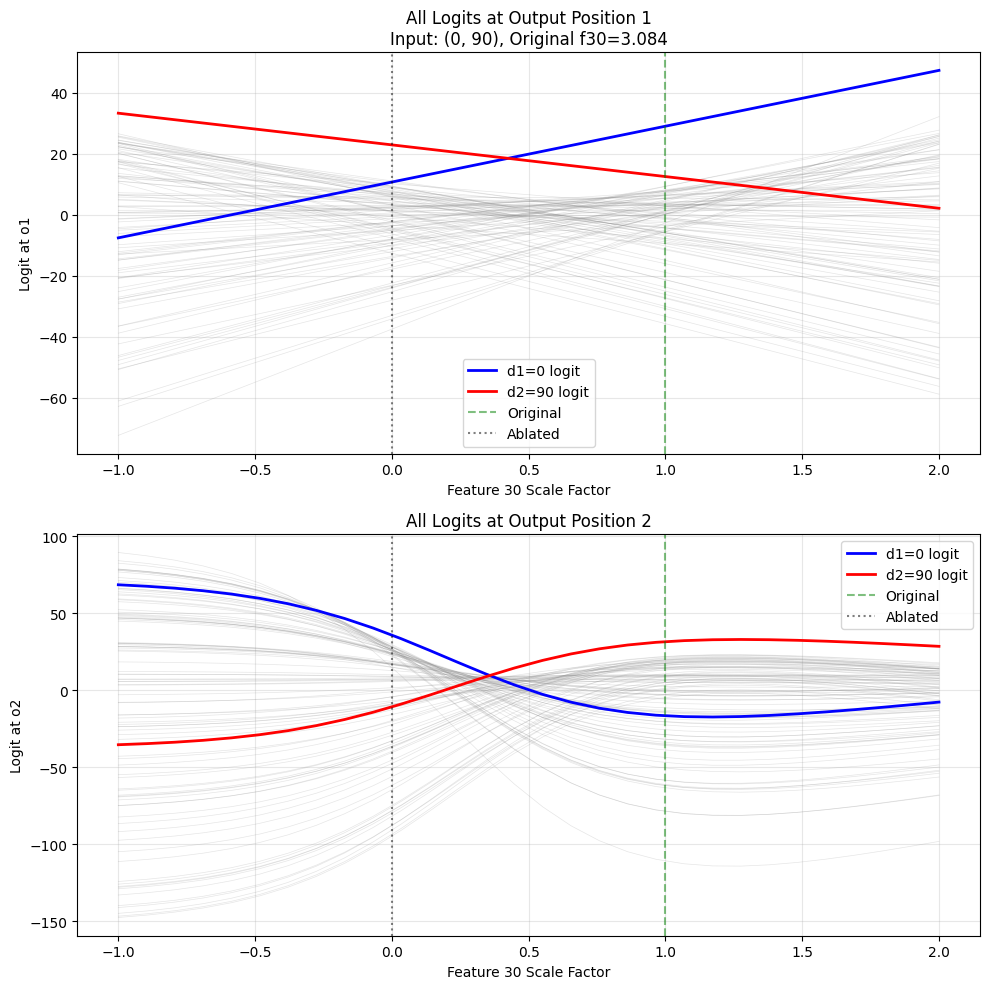


CROSSOVER ANALYSIS

📍 O1 Logits cross over at scale ≈ 0.345
   At this point: d1 logit = 17.005, d2 logit = 19.294

📍 O2 Logits cross over at scale ≈ 0.345
   At this point: d1 logit = 10.485, d2 logit = 8.862


In [ ]:
# let's focus on the logits for a particular input example (91, 83).
# plot red line for d2=83 logit, blue line for d1=91 logit, and grey lines for all other logits
# ==> should be 100 lines in total!

# Find index for example input
d1_val, d2_val = 0, 90
mask = (d1_all == d1_val) & (d2_all == d2_val)
if mask.sum() == 0:
    print(f"Input ({d1_val}, {d2_val}) not found in dataset!")
else:
    input_idx = torch.where(mask)[0][0].item()
    print(f"Found input ({d1_val}, {d2_val}) at index {input_idx}")
    
    # Get the input and original SAE activations
    inputs_i = all_ds[input_idx][0].unsqueeze(0).to(DEVICE)
    z_orig = sae_acts_all[input_idx].clone().to(DEVICE)
    feat_orig = z_orig[SPECIAL_FEAT_IDX].item()
    
    print(f"Original feature {SPECIAL_FEAT_IDX} activation: {feat_orig:.4f}")
    
    # Test scale factors from -1 to 2
    scale_factors = np.linspace(-1.0, 2.0, 30)
    
    # Storage for all logits at o1 and o2
    all_logits_o1 = []  # Will be shape [n_scales, n_digits]
    all_logits_o2 = []  # Will be shape [n_scales, n_digits]
    
    hook_name_resid = f"blocks.0.hook_resid_post"
    
    for scale in tqdm(scale_factors, desc="Testing scales"):
        z_scaled = z_orig.clone()
        z_scaled[SPECIAL_FEAT_IDX] = feat_orig * scale
        
        recon = sae.decode(z_scaled.unsqueeze(0))
        
        with torch.no_grad():
            patched_logits = model.run_with_hooks(
                inputs_i,
                fwd_hooks=[(hook_name_resid, make_sae_patch_hook(recon, act_mean, SEP_TOKEN_INDEX))]
            )
        
        # Get logits at o1 (position -2) and o2 (position -1) for ALL digits
        logits_o1 = patched_logits[0, -2, :N_DIGITS].cpu().numpy()
        logits_o2 = patched_logits[0, -1, :N_DIGITS].cpu().numpy()
        all_logits_o1.append(logits_o1)
        all_logits_o2.append(logits_o2)
    
    all_logits_o1 = np.array(all_logits_o1)  # [n_scales, n_digits]
    all_logits_o2 = np.array(all_logits_o2)  # [n_scales, n_digits]
    
    # Create 2-row plot
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))
    
    # Plot o1 logits (top row)
    ax1 = axes[0]
    
    # Plot all other logits in grey
    for digit in range(N_DIGITS):
        if digit != d1_val and digit != d2_val:
            ax1.plot(scale_factors, all_logits_o1[:, digit], 'grey', alpha=0.2, linewidth=0.5)
    
    # Plot d1 and d2 logits on top
    ax1.plot(scale_factors, all_logits_o1[:, d1_val], 'b-', linewidth=2, label=f'd1={d1_val} logit')
    ax1.plot(scale_factors, all_logits_o1[:, d2_val], 'r-', linewidth=2, label=f'd2={d2_val} logit')
    
    # Mark original activation point
    ax1.axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='Original')
    ax1.axvline(x=0.0, color='black', linestyle=':', alpha=0.5, label='Ablated')
    
    ax1.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax1.set_ylabel('Logit at o1')
    ax1.set_title(f'All Logits at Output Position 1
Input: ({d1_val}, {d2_val}), Original f{SPECIAL_FEAT_IDX}={feat_orig:.3f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot o2 logits (bottom row)
    ax2 = axes[1]
    
    # Plot all other logits in grey
    for digit in range(N_DIGITS):
        if digit != d1_val and digit != d2_val:
            ax2.plot(scale_factors, all_logits_o2[:, digit], 'grey', alpha=0.2, linewidth=0.5)
    
    # Plot d1 and d2 logits on top
    ax2.plot(scale_factors, all_logits_o2[:, d1_val], 'b-', linewidth=2, label=f'd1={d1_val} logit')
    ax2.plot(scale_factors, all_logits_o2[:, d2_val], 'r-', linewidth=2, label=f'd2={d2_val} logit')
    
    # Mark original activation point
    ax2.axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='Original')
    ax2.axvline(x=0.0, color='black', linestyle=':', alpha=0.5, label='Ablated')
    
    ax2.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax2.set_ylabel('Logit at o2')
    ax2.set_title(f'All Logits at Output Position 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax2.set_ylabel('Logit at o2')
    ax2.set_title(f'All Logits at Output Position 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if SAVE_DIR:
        plt.savefig(os.path.join(SAVE_DIR, f'all_logits_o1_o2_f{SPECIAL_FEAT_IDX}_input_{d1_val}_{d2_val}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print crossover points for both positions
    d1_logits_o1 = all_logits_o1[:, d1_val]
    d2_logits_o1 = all_logits_o1[:, d2_val]
    diff_o1 = d1_logits_o1 - d2_logits_o1
    
    d1_logits_o2 = all_logits_o2[:, d1_val]
    d2_logits_o2 = all_logits_o2[:, d2_val]
    diff_o2 = d1_logits_o2 - d2_logits_o2
    
    print("
" + "="*60)
    print("CROSSOVER ANALYSIS")
    print("="*60)
    
    # Find where sign changes (crossover) for o1
    sign_changes_o1 = np.where(np.diff(np.sign(diff_o1)))[0]
    if len(sign_changes_o1) > 0:
        crossover_idx_o1 = sign_changes_o1[0]
        crossover_scale_o1 = scale_factors[crossover_idx_o1]
        print(f"
📍 O1 Logits cross over at scale ≈ {crossover_scale_o1:.3f}")
        print(f"   At this point: d1 logit = {d1_logits_o1[crossover_idx_o1]:.3f}, d2 logit = {d2_logits_o1[crossover_idx_o1]:.3f}")
    else:
        print(f"
❌ O1: No crossover detected in range [{scale_factors[0]:.1f}, {scale_factors[-1]:.1f}]")
        if d1_logits_o1[0] > d2_logits_o1[0]:
            print("   d1 logit remains higher throughout")
        else:
            print("   d2 logit remains higher throughout")
    
    # Find where sign changes (crossover) for o2
    sign_changes_o2 = np.where(np.diff(np.sign(diff_o2)))[0]
    if len(sign_changes_o2) > 0:
        crossover_idx_o2 = sign_changes_o2[0]
        crossover_scale_o2 = scale_factors[crossover_idx_o2]
        print(f"
📍 O2 Logits cross over at scale ≈ {crossover_scale_o2:.3f}")
        print(f"   At this point: d1 logit = {d1_logits_o2[crossover_idx_o2]:.3f}, d2 logit = {d2_logits_o2[crossover_idx_o2]:.3f}")
    else:
        print(f"
❌ O2: No crossover detected in range [{scale_factors[0]:.1f}, {scale_factors[-1]:.1f}]")
        if d1_logits_o2[0] > d2_logits_o2[0]:
            print("   d1 logit remains higher throughout")
        else:
            print("   d2 logit remains higher throughout")

Found input (0, 90) at index 6411
Original feature 30 activation: 3.0842


Testing scales: 100%|██████████| 30/30 [00:00<00:00, 263.11it/s]


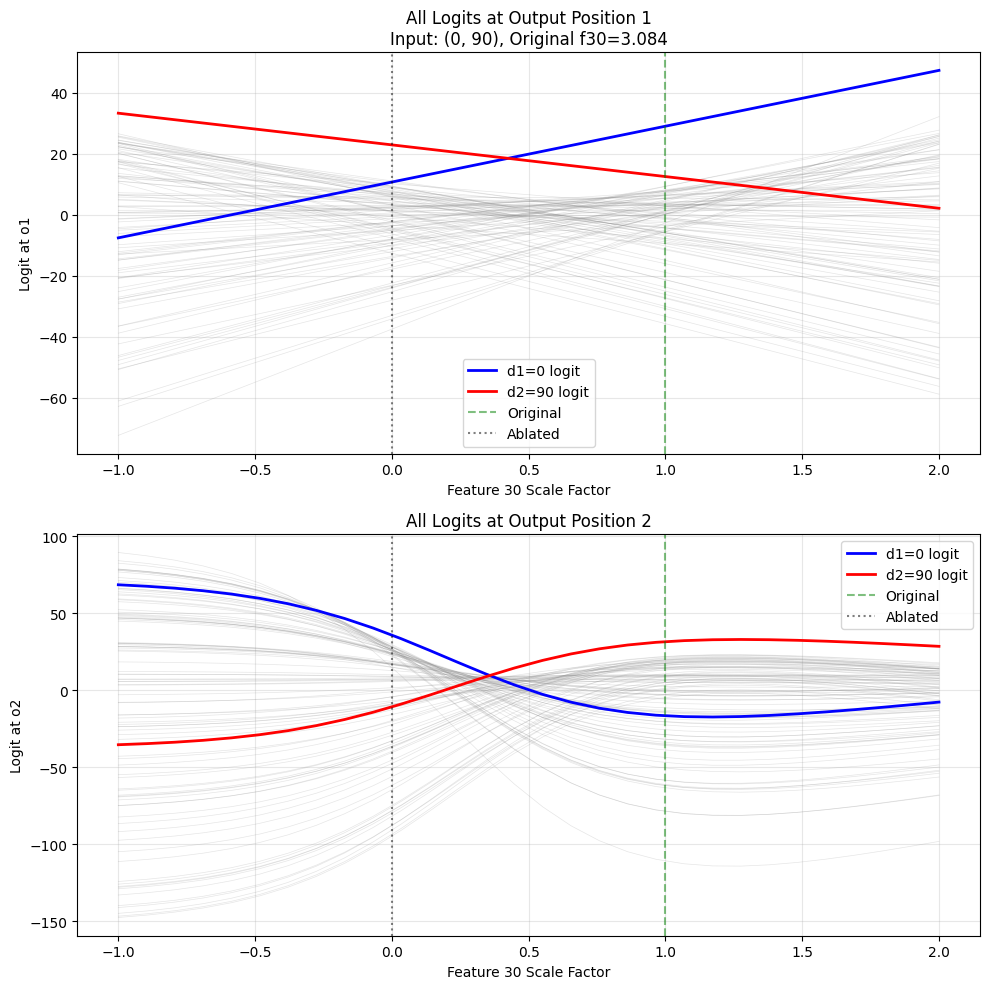


CROSSOVER ANALYSIS

📍 O1 Logits cross over at scale ≈ 0.345
   At this point: d1 logit = 17.005, d2 logit = 19.294
   Model output: (90, 0)

📍 O2 Logits cross over at scale ≈ 0.345
   At this point: d1 logit = 10.485, d2 logit = 8.862
   Model output: (90, 0)


In [ ]:
# let's focus on the logits for a particular input example (91, 83).
# plot red line for d2=83 logit, blue line for d1=91 logit, and grey lines for all other logits
# ==> should be 100 lines in total!

# Find index for example input
d1_val, d2_val = 0, 90
mask = (d1_all == d1_val) & (d2_all == d2_val)
if mask.sum() == 0:
    print(f"Input ({d1_val}, {d2_val}) not found in dataset!")
else:
    input_idx = torch.where(mask)[0][0].item()
    print(f"Found input ({d1_val}, {d2_val}) at index {input_idx}")
    
    # Get the input and original SAE activations
    inputs_i = all_ds[input_idx][0].unsqueeze(0).to(DEVICE)
    z_orig = sae_acts_all[input_idx].clone().to(DEVICE)
    feat_orig = z_orig[SPECIAL_FEAT_IDX].item()
    
    print(f"Original feature {SPECIAL_FEAT_IDX} activation: {feat_orig:.4f}")
    
    # Test scale factors from -1 to 2
    scale_factors = np.linspace(-1.0, 2.0, 30)
    
    # Storage for all logits at o1 and o2
    all_logits_o1 = []  # Will be shape [n_scales, n_digits]
    all_logits_o2 = []  # Will be shape [n_scales, n_digits]
    
    hook_name_resid = f"blocks.0.hook_resid_post"
    
    for scale in tqdm(scale_factors, desc="Testing scales"):
        z_scaled = z_orig.clone()
        z_scaled[SPECIAL_FEAT_IDX] = feat_orig * scale
        
        recon = sae.decode(z_scaled.unsqueeze(0))
        
        with torch.no_grad():
            patched_logits = model.run_with_hooks(
                inputs_i,
                fwd_hooks=[(hook_name_resid, make_sae_patch_hook(recon, act_mean, SEP_TOKEN_INDEX))]
            )
        
        # Get logits at o1 (position -2) and o2 (position -1) for ALL digits
        logits_o1 = patched_logits[0, -2, :N_DIGITS].cpu().numpy()
        logits_o2 = patched_logits[0, -1, :N_DIGITS].cpu().numpy()
        all_logits_o1.append(logits_o1)
        all_logits_o2.append(logits_o2)
    
    all_logits_o1 = np.array(all_logits_o1)  # [n_scales, n_digits]
    all_logits_o2 = np.array(all_logits_o2)  # [n_scales, n_digits]
    
    # Create 2-row plot
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))
    
    # Plot o1 logits (top row)
    ax1 = axes[0]
    
    # Plot all other logits in grey
    for digit in range(N_DIGITS):
        if digit != d1_val and digit != d2_val:
            ax1.plot(scale_factors, all_logits_o1[:, digit], 'grey', alpha=0.2, linewidth=0.5)
    
    # Plot d1 and d2 logits on top
    ax1.plot(scale_factors, all_logits_o1[:, d1_val], 'b-', linewidth=2, label=f'd1={d1_val} logit')
    ax1.plot(scale_factors, all_logits_o1[:, d2_val], 'r-', linewidth=2, label=f'd2={d2_val} logit')
    
    # Mark original activation point
    ax1.axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='Original')
    ax1.axvline(x=0.0, color='black', linestyle=':', alpha=0.5, label='Ablated')
    
    ax1.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax1.set_ylabel('Logit at o1')
    ax1.set_title(f'All Logits at Output Position 1
Input: ({d1_val}, {d2_val}), Original f{SPECIAL_FEAT_IDX}={feat_orig:.3f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot o2 logits (bottom row)
    ax2 = axes[1]
    
    # Plot all other logits in grey
    for digit in range(N_DIGITS):
        if digit != d1_val and digit != d2_val:
            ax2.plot(scale_factors, all_logits_o2[:, digit], 'grey', alpha=0.2, linewidth=0.5)
    
    # Plot d1 and d2 logits on top
    ax2.plot(scale_factors, all_logits_o2[:, d1_val], 'b-', linewidth=2, label=f'd1={d1_val} logit')
    ax2.plot(scale_factors, all_logits_o2[:, d2_val], 'r-', linewidth=2, label=f'd2={d2_val} logit')
    
    # Mark original activation point
    ax2.axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='Original')
    ax2.axvline(x=0.0, color='black', linestyle=':', alpha=0.5, label='Ablated')
    
    ax2.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax2.set_ylabel('Logit at o2')
    ax2.set_title(f'All Logits at Output Position 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax2.set_ylabel('Logit at o2')
    ax2.set_title(f'All Logits at Output Position 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if SAVE_DIR:
        plt.savefig(os.path.join(SAVE_DIR, f'all_logits_o1_o2_f{SPECIAL_FEAT_IDX}_input_{d1_val}_{d2_val}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print crossover points for both positions
    d1_logits_o1 = all_logits_o1[:, d1_val]
    d2_logits_o1 = all_logits_o1[:, d2_val]
    diff_o1 = d1_logits_o1 - d2_logits_o1
    
    d1_logits_o2 = all_logits_o2[:, d1_val]
    d2_logits_o2 = all_logits_o2[:, d2_val]
    diff_o2 = d1_logits_o2 - d2_logits_o2
    
    print("
" + "="*60)
    print("CROSSOVER ANALYSIS")
    print("="*60)
    
    # Find where sign changes (crossover) for o1
    sign_changes_o1 = np.where(np.diff(np.sign(diff_o1)))[0]
    if len(sign_changes_o1) > 0:
        crossover_idx_o1 = sign_changes_o1[0]
        crossover_scale_o1 = scale_factors[crossover_idx_o1]
        output_o1_at_crossover = all_logits_o1[crossover_idx_o1].argmax()
        output_o2_at_crossover_o1 = all_logits_o2[crossover_idx_o1].argmax()
        print(f"
📍 O1 Logits cross over at scale ≈ {crossover_scale_o1:.3f}")
        print(f"   At this point: d1 logit = {d1_logits_o1[crossover_idx_o1]:.3f}, d2 logit = {d2_logits_o1[crossover_idx_o1]:.3f}")
        print(f"   Model output: ({output_o1_at_crossover}, {output_o2_at_crossover_o1})")
    else:
        print(f"
❌ O1: No crossover detected in range [{scale_factors[0]:.1f}, {scale_factors[-1]:.1f}]")
        if d1_logits_o1[0] > d2_logits_o1[0]:
            print("   d1 logit remains higher throughout")
        else:
            print("   d2 logit remains higher throughout")
    
    # Find where sign changes (crossover) for o2
    sign_changes_o2 = np.where(np.diff(np.sign(diff_o2)))[0]
    if len(sign_changes_o2) > 0:
        crossover_idx_o2 = sign_changes_o2[0]
        crossover_scale_o2 = scale_factors[crossover_idx_o2]
        output_o1_at_crossover_o2 = all_logits_o1[crossover_idx_o2].argmax()
        output_o2_at_crossover = all_logits_o2[crossover_idx_o2].argmax()
        print(f"
📍 O2 Logits cross over at scale ≈ {crossover_scale_o2:.3f}")
        print(f"   At this point: d1 logit = {d1_logits_o2[crossover_idx_o2]:.3f}, d2 logit = {d2_logits_o2[crossover_idx_o2]:.3f}")
        print(f"   Model output: ({output_o1_at_crossover_o2}, {output_o2_at_crossover})")
    else:
        print(f"
❌ O2: No crossover detected in range [{scale_factors[0]:.1f}, {scale_factors[-1]:.1f}]")
        if d1_logits_o2[0] > d2_logits_o2[0]:
            print("   d1 logit remains higher throughout")
        else:
            print("   d2 logit remains higher throughout")

Found input (91, 83) at index 7534
Original feature 30 activation: 3.5068


Testing scales: 100%|██████████| 30/30 [00:00<00:00, 247.69it/s]


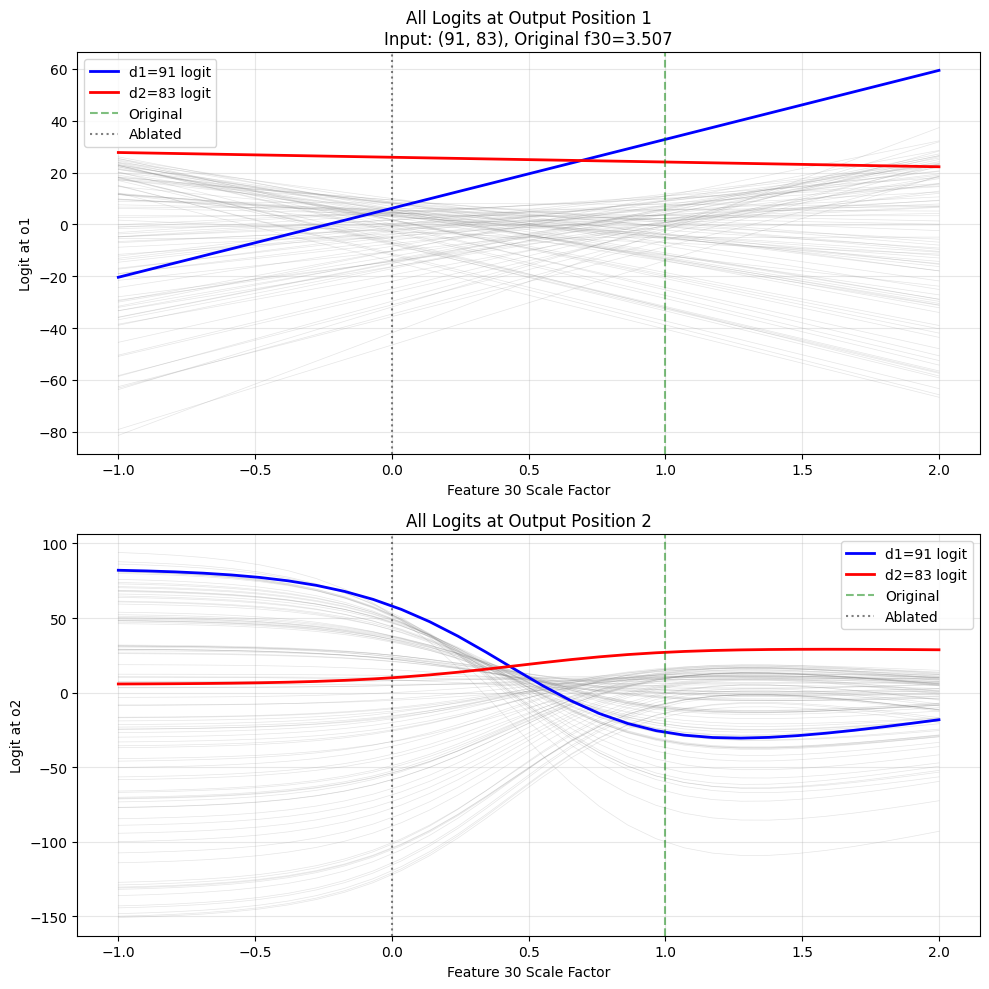


CROSSOVER ANALYSIS

📍 O1 Logits cross over at scale ≈ 0.655
   At this point: d1 logit = 23.670, d2 logit = 24.733
   Model output: (83, 83)

📍 O2 Logits cross over at scale ≈ 0.345
   At this point: d1 logit = 27.062, d2 logit = 15.700
   Model output: (83, 91)


In [ ]:
# let's focus on the logits for a particular input example (91, 83).
# plot red line for d2=83 logit, blue line for d1=91 logit, and grey lines for all other logits
# ==> should be 100 lines in total!

# Find index for example input
d1_val, d2_val = 91, 83
mask = (d1_all == d1_val) & (d2_all == d2_val)
if mask.sum() == 0:
    print(f"Input ({d1_val}, {d2_val}) not found in dataset!")
else:
    input_idx = torch.where(mask)[0][0].item()
    print(f"Found input ({d1_val}, {d2_val}) at index {input_idx}")
    
    # Get the input and original SAE activations
    inputs_i = all_ds[input_idx][0].unsqueeze(0).to(DEVICE)
    z_orig = sae_acts_all[input_idx].clone().to(DEVICE)
    feat_orig = z_orig[SPECIAL_FEAT_IDX].item()
    
    print(f"Original feature {SPECIAL_FEAT_IDX} activation: {feat_orig:.4f}")
    
    # Test scale factors from -1 to 2
    scale_factors = np.linspace(-1.0, 2.0, 30)
    
    # Storage for all logits at o1 and o2
    all_logits_o1 = []  # Will be shape [n_scales, n_digits]
    all_logits_o2 = []  # Will be shape [n_scales, n_digits]
    
    hook_name_resid = f"blocks.0.hook_resid_post"
    
    for scale in tqdm(scale_factors, desc="Testing scales"):
        z_scaled = z_orig.clone()
        z_scaled[SPECIAL_FEAT_IDX] = feat_orig * scale
        
        recon = sae.decode(z_scaled.unsqueeze(0))
        
        with torch.no_grad():
            patched_logits = model.run_with_hooks(
                inputs_i,
                fwd_hooks=[(hook_name_resid, make_sae_patch_hook(recon, act_mean, SEP_TOKEN_INDEX))]
            )
        
        # Get logits at o1 (position -2) and o2 (position -1) for ALL digits
        logits_o1 = patched_logits[0, -2, :N_DIGITS].cpu().numpy()
        logits_o2 = patched_logits[0, -1, :N_DIGITS].cpu().numpy()
        all_logits_o1.append(logits_o1)
        all_logits_o2.append(logits_o2)
    
    all_logits_o1 = np.array(all_logits_o1)  # [n_scales, n_digits]
    all_logits_o2 = np.array(all_logits_o2)  # [n_scales, n_digits]
    
    # Create 2-row plot
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))
    
    # Plot o1 logits (top row)
    ax1 = axes[0]
    
    # Plot all other logits in grey
    for digit in range(N_DIGITS):
        if digit != d1_val and digit != d2_val:
            ax1.plot(scale_factors, all_logits_o1[:, digit], 'grey', alpha=0.2, linewidth=0.5)
    
    # Plot d1 and d2 logits on top
    ax1.plot(scale_factors, all_logits_o1[:, d1_val], 'b-', linewidth=2, label=f'd1={d1_val} logit')
    ax1.plot(scale_factors, all_logits_o1[:, d2_val], 'r-', linewidth=2, label=f'd2={d2_val} logit')
    
    # Mark original activation point
    ax1.axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='Original')
    ax1.axvline(x=0.0, color='black', linestyle=':', alpha=0.5, label='Ablated')
    
    ax1.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax1.set_ylabel('Logit at o1')
    ax1.set_title(f'All Logits at Output Position 1
Input: ({d1_val}, {d2_val}), Original f{SPECIAL_FEAT_IDX}={feat_orig:.3f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot o2 logits (bottom row)
    ax2 = axes[1]
    
    # Plot all other logits in grey
    for digit in range(N_DIGITS):
        if digit != d1_val and digit != d2_val:
            ax2.plot(scale_factors, all_logits_o2[:, digit], 'grey', alpha=0.2, linewidth=0.5)
    
    # Plot d1 and d2 logits on top
    ax2.plot(scale_factors, all_logits_o2[:, d1_val], 'b-', linewidth=2, label=f'd1={d1_val} logit')
    ax2.plot(scale_factors, all_logits_o2[:, d2_val], 'r-', linewidth=2, label=f'd2={d2_val} logit')
    
    # Mark original activation point
    ax2.axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='Original')
    ax2.axvline(x=0.0, color='black', linestyle=':', alpha=0.5, label='Ablated')
    
    ax2.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax2.set_ylabel('Logit at o2')
    ax2.set_title(f'All Logits at Output Position 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax2.set_ylabel('Logit at o2')
    ax2.set_title(f'All Logits at Output Position 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if SAVE_DIR:
        plt.savefig(os.path.join(SAVE_DIR, f'all_logits_o1_o2_f{SPECIAL_FEAT_IDX}_input_{d1_val}_{d2_val}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print crossover points for both positions
    d1_logits_o1 = all_logits_o1[:, d1_val]
    d2_logits_o1 = all_logits_o1[:, d2_val]
    diff_o1 = d1_logits_o1 - d2_logits_o1
    
    d1_logits_o2 = all_logits_o2[:, d1_val]
    d2_logits_o2 = all_logits_o2[:, d2_val]
    diff_o2 = d1_logits_o2 - d2_logits_o2
    
    print("
" + "="*60)
    print("CROSSOVER ANALYSIS")
    print("="*60)
    
    # Find where sign changes (crossover) for o1
    sign_changes_o1 = np.where(np.diff(np.sign(diff_o1)))[0]
    if len(sign_changes_o1) > 0:
        crossover_idx_o1 = sign_changes_o1[0]
        crossover_scale_o1 = scale_factors[crossover_idx_o1]
        output_o1_at_crossover = all_logits_o1[crossover_idx_o1].argmax()
        output_o2_at_crossover_o1 = all_logits_o2[crossover_idx_o1].argmax()
        print(f"
📍 O1 Logits cross over at scale ≈ {crossover_scale_o1:.3f}")
        print(f"   At this point: d1 logit = {d1_logits_o1[crossover_idx_o1]:.3f}, d2 logit = {d2_logits_o1[crossover_idx_o1]:.3f}")
        print(f"   Model output: ({output_o1_at_crossover}, {output_o2_at_crossover_o1})")
    else:
        print(f"
❌ O1: No crossover detected in range [{scale_factors[0]:.1f}, {scale_factors[-1]:.1f}]")
        if d1_logits_o1[0] > d2_logits_o1[0]:
            print("   d1 logit remains higher throughout")
        else:
            print("   d2 logit remains higher throughout")
    
    # Find where sign changes (crossover) for o2
    sign_changes_o2 = np.where(np.diff(np.sign(diff_o2)))[0]
    if len(sign_changes_o2) > 0:
        crossover_idx_o2 = sign_changes_o2[0]
        crossover_scale_o2 = scale_factors[crossover_idx_o2]
        output_o1_at_crossover_o2 = all_logits_o1[crossover_idx_o2].argmax()
        output_o2_at_crossover = all_logits_o2[crossover_idx_o2].argmax()
        print(f"
📍 O2 Logits cross over at scale ≈ {crossover_scale_o2:.3f}")
        print(f"   At this point: d1 logit = {d1_logits_o2[crossover_idx_o2]:.3f}, d2 logit = {d2_logits_o2[crossover_idx_o2]:.3f}")
        print(f"   Model output: ({output_o1_at_crossover_o2}, {output_o2_at_crossover})")
    else:
        print(f"
❌ O2: No crossover detected in range [{scale_factors[0]:.1f}, {scale_factors[-1]:.1f}]")
        if d1_logits_o2[0] > d2_logits_o2[0]:
            print("   d1 logit remains higher throughout")
        else:
            print("   d2 logit remains higher throughout")

Found input (91, 83) at index 7534
Original feature 30 activation: 3.5068


Testing scales: 100%|██████████| 30/30 [00:00<00:00, 287.83it/s]


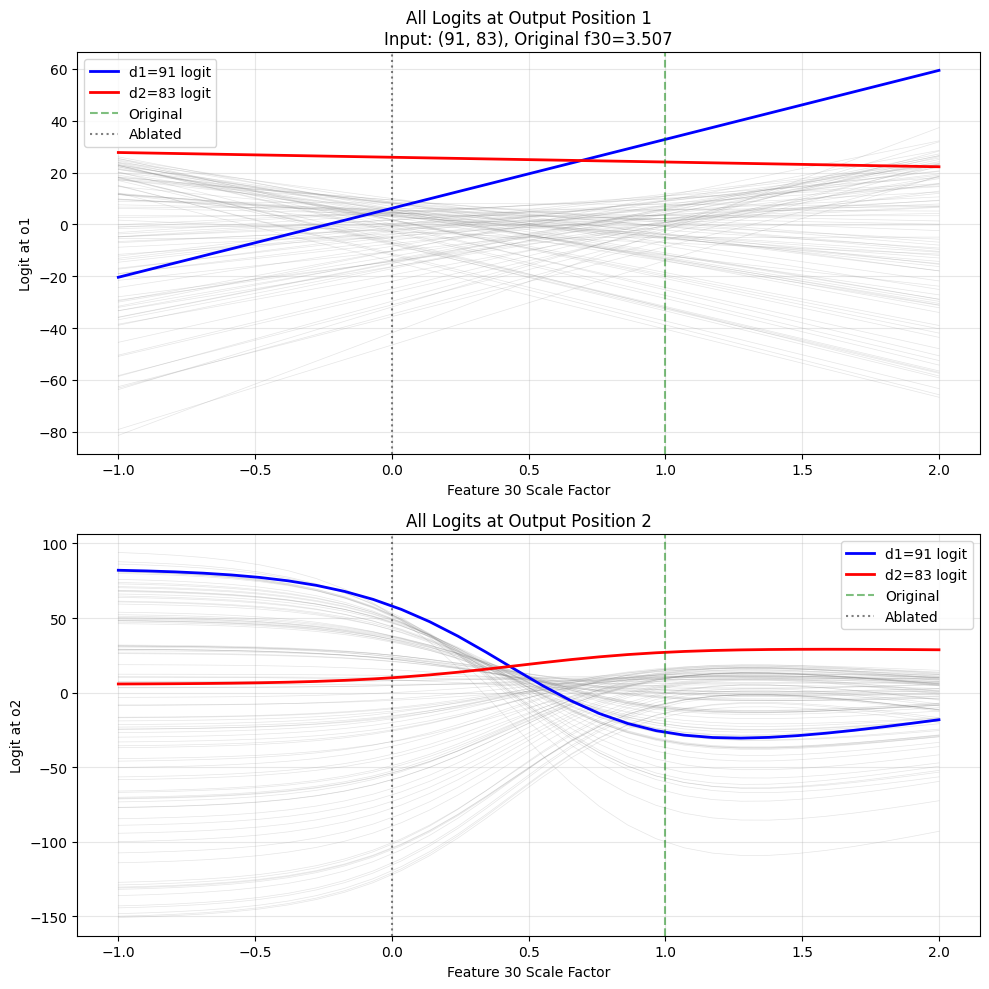


CROSSOVER ANALYSIS

Original model output: (91, 83)
Input: (91, 83)

📍 O1 Logits cross over at scale ≈ 0.655
   At this point: d1 logit = 23.670, d2 logit = 24.733
   Model output: (83, 83)  [original: (91, 83)]

📍 O2 Logits cross over at scale ≈ 0.345
   At this point: d1 logit = 27.062, d2 logit = 15.700
   Model output: (83, 91)  [original: (91, 83)]


In [ ]:
# let's focus on the logits for a particular input example (91, 83).
# plot red line for d2=83 logit, blue line for d1=91 logit, and grey lines for all other logits
# ==> should be 100 lines in total!

# Find index for example input
d1_val, d2_val = 91, 83
mask = (d1_all == d1_val) & (d2_all == d2_val)
if mask.sum() == 0:
    print(f"Input ({d1_val}, {d2_val}) not found in dataset!")
else:
    input_idx = torch.where(mask)[0][0].item()
    print(f"Found input ({d1_val}, {d2_val}) at index {input_idx}")
    
    # Get the input and original SAE activations
    inputs_i = all_ds[input_idx][0].unsqueeze(0).to(DEVICE)
    z_orig = sae_acts_all[input_idx].clone().to(DEVICE)
    feat_orig = z_orig[SPECIAL_FEAT_IDX].item()
    
    print(f"Original feature {SPECIAL_FEAT_IDX} activation: {feat_orig:.4f}")
    
    # Test scale factors from -1 to 2
    scale_factors = np.linspace(-1.0, 2.0, 30)
    
    # Storage for all logits at o1 and o2
    all_logits_o1 = []  # Will be shape [n_scales, n_digits]
    all_logits_o2 = []  # Will be shape [n_scales, n_digits]
    
    hook_name_resid = f"blocks.0.hook_resid_post"
    
    for scale in tqdm(scale_factors, desc="Testing scales"):
        z_scaled = z_orig.clone()
        z_scaled[SPECIAL_FEAT_IDX] = feat_orig * scale
        
        recon = sae.decode(z_scaled.unsqueeze(0))
        
        with torch.no_grad():
            patched_logits = model.run_with_hooks(
                inputs_i,
                fwd_hooks=[(hook_name_resid, make_sae_patch_hook(recon, act_mean, SEP_TOKEN_INDEX))]
            )
        
        # Get logits at o1 (position -2) and o2 (position -1) for ALL digits
        logits_o1 = patched_logits[0, -2, :N_DIGITS].cpu().numpy()
        logits_o2 = patched_logits[0, -1, :N_DIGITS].cpu().numpy()
        all_logits_o1.append(logits_o1)
        all_logits_o2.append(logits_o2)
    
    all_logits_o1 = np.array(all_logits_o1)  # [n_scales, n_digits]
    all_logits_o2 = np.array(all_logits_o2)  # [n_scales, n_digits]
    
    # Create 2-row plot
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))
    
    # Plot o1 logits (top row)
    ax1 = axes[0]
    
    # Plot all other logits in grey
    for digit in range(N_DIGITS):
        if digit != d1_val and digit != d2_val:
            ax1.plot(scale_factors, all_logits_o1[:, digit], 'grey', alpha=0.2, linewidth=0.5)
    
    # Plot d1 and d2 logits on top
    ax1.plot(scale_factors, all_logits_o1[:, d1_val], 'b-', linewidth=2, label=f'd1={d1_val} logit')
    ax1.plot(scale_factors, all_logits_o1[:, d2_val], 'r-', linewidth=2, label=f'd2={d2_val} logit')
    
    # Mark original activation point
    ax1.axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='Original')
    ax1.axvline(x=0.0, color='black', linestyle=':', alpha=0.5, label='Ablated')
    
    ax1.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax1.set_ylabel('Logit at o1')
    ax1.set_title(f'All Logits at Output Position 1
Input: ({d1_val}, {d2_val}), Original f{SPECIAL_FEAT_IDX}={feat_orig:.3f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot o2 logits (bottom row)
    ax2 = axes[1]
    
    # Plot all other logits in grey
    for digit in range(N_DIGITS):
        if digit != d1_val and digit != d2_val:
            ax2.plot(scale_factors, all_logits_o2[:, digit], 'grey', alpha=0.2, linewidth=0.5)
    
    # Plot d1 and d2 logits on top
    ax2.plot(scale_factors, all_logits_o2[:, d1_val], 'b-', linewidth=2, label=f'd1={d1_val} logit')
    ax2.plot(scale_factors, all_logits_o2[:, d2_val], 'r-', linewidth=2, label=f'd2={d2_val} logit')
    
    # Mark original activation point
    ax2.axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='Original')
    ax2.axvline(x=0.0, color='black', linestyle=':', alpha=0.5, label='Ablated')
    
    ax2.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax2.set_ylabel('Logit at o2')
    ax2.set_title(f'All Logits at Output Position 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax2.set_ylabel('Logit at o2')
    ax2.set_title(f'All Logits at Output Position 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if SAVE_DIR:
        plt.savefig(os.path.join(SAVE_DIR, f'all_logits_o1_o2_f{SPECIAL_FEAT_IDX}_input_{d1_val}_{d2_val}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Get original outputs (at scale=1.0)
    original_scale_idx = np.argmin(np.abs(scale_factors - 1.0))
    original_output_o1 = all_logits_o1[original_scale_idx].argmax()
    original_output_o2 = all_logits_o2[original_scale_idx].argmax()
    
    # Print crossover points for both positions
    d1_logits_o1 = all_logits_o1[:, d1_val]
    d2_logits_o1 = all_logits_o1[:, d2_val]
    diff_o1 = d1_logits_o1 - d2_logits_o1
    
    d1_logits_o2 = all_logits_o2[:, d1_val]
    d2_logits_o2 = all_logits_o2[:, d2_val]
    diff_o2 = d1_logits_o2 - d2_logits_o2
    
    print("
" + "="*60)
    print("CROSSOVER ANALYSIS")
    print("="*60)
    print(f"
Original model output: ({original_output_o1}, {original_output_o2})")
    print(f"Input: ({d1_val}, {d2_val})")
    
    # Find where sign changes (crossover) for o1
    sign_changes_o1 = np.where(np.diff(np.sign(diff_o1)))[0]
    if len(sign_changes_o1) > 0:
        crossover_idx_o1 = sign_changes_o1[0]
        crossover_scale_o1 = scale_factors[crossover_idx_o1]
        output_o1_at_crossover = all_logits_o1[crossover_idx_o1].argmax()
        output_o2_at_crossover_o1 = all_logits_o2[crossover_idx_o1].argmax()
        print(f"
📍 O1 Logits cross over at scale ≈ {crossover_scale_o1:.3f}")
        print(f"   At this point: d1 logit = {d1_logits_o1[crossover_idx_o1]:.3f}, d2 logit = {d2_logits_o1[crossover_idx_o1]:.3f}")
        print(f"   Model output: ({output_o1_at_crossover}, {output_o2_at_crossover_o1})  [original: ({original_output_o1}, {original_output_o2})]")
    else:
        print(f"
❌ O1: No crossover detected in range [{scale_factors[0]:.1f}, {scale_factors[-1]:.1f}]")
        if d1_logits_o1[0] > d2_logits_o1[0]:
            print("   d1 logit remains higher throughout")
        else:
            print("   d2 logit remains higher throughout")
    
    # Find where sign changes (crossover) for o2
    sign_changes_o2 = np.where(np.diff(np.sign(diff_o2)))[0]
    if len(sign_changes_o2) > 0:
        crossover_idx_o2 = sign_changes_o2[0]
        crossover_scale_o2 = scale_factors[crossover_idx_o2]
        output_o1_at_crossover_o2 = all_logits_o1[crossover_idx_o2].argmax()
        output_o2_at_crossover = all_logits_o2[crossover_idx_o2].argmax()
        print(f"
📍 O2 Logits cross over at scale ≈ {crossover_scale_o2:.3f}")
        print(f"   At this point: d1 logit = {d1_logits_o2[crossover_idx_o2]:.3f}, d2 logit = {d2_logits_o2[crossover_idx_o2]:.3f}")
        print(f"   Model output: ({output_o1_at_crossover_o2}, {output_o2_at_crossover})  [original: ({original_output_o1}, {original_output_o2})]")
    else:
        print(f"
❌ O2: No crossover detected in range [{scale_factors[0]:.1f}, {scale_factors[-1]:.1f}]")
        if d1_logits_o2[0] > d2_logits_o2[0]:
            print("   d1 logit remains higher throughout")
        else:
            print("   d2 logit remains higher throughout")

In [ ]:
SPECIAL_FEAT_IDX = 84

Found input (91, 83) at index 7534
Original feature 84 activation: 0.0000


Testing scales: 100%|██████████| 30/30 [00:00<00:00, 271.04it/s]


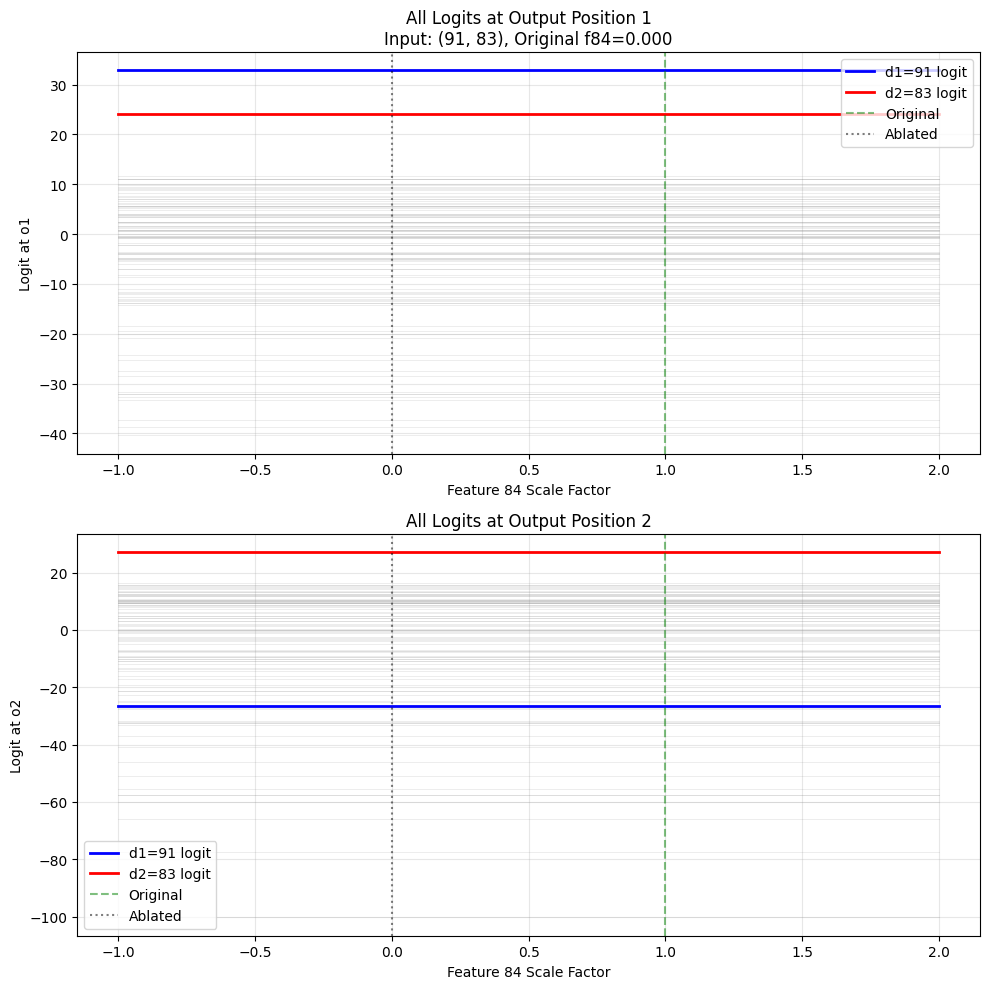


CROSSOVER ANALYSIS

Original model output: (91, 83)
Input: (91, 83)

❌ O1: No crossover detected in range [-1.0, 2.0]
   d1 logit remains higher throughout

❌ O2: No crossover detected in range [-1.0, 2.0]
   d2 logit remains higher throughout


In [ ]:
# let's focus on the logits for a particular input example (91, 83).
# plot red line for d2=83 logit, blue line for d1=91 logit, and grey lines for all other logits
# ==> should be 100 lines in total!

# Find index for example input
d1_val, d2_val = 91, 83
mask = (d1_all == d1_val) & (d2_all == d2_val)
if mask.sum() == 0:
    print(f"Input ({d1_val}, {d2_val}) not found in dataset!")
else:
    input_idx = torch.where(mask)[0][0].item()
    print(f"Found input ({d1_val}, {d2_val}) at index {input_idx}")
    
    # Get the input and original SAE activations
    inputs_i = all_ds[input_idx][0].unsqueeze(0).to(DEVICE)
    z_orig = sae_acts_all[input_idx].clone().to(DEVICE)
    feat_orig = z_orig[SPECIAL_FEAT_IDX].item()
    
    print(f"Original feature {SPECIAL_FEAT_IDX} activation: {feat_orig:.4f}")
    
    # Test scale factors from -1 to 2
    scale_factors = np.linspace(-1.0, 2.0, 30)
    
    # Storage for all logits at o1 and o2
    all_logits_o1 = []  # Will be shape [n_scales, n_digits]
    all_logits_o2 = []  # Will be shape [n_scales, n_digits]
    
    hook_name_resid = f"blocks.0.hook_resid_post"
    
    for scale in tqdm(scale_factors, desc="Testing scales"):
        z_scaled = z_orig.clone()
        z_scaled[SPECIAL_FEAT_IDX] = feat_orig * scale
        
        recon = sae.decode(z_scaled.unsqueeze(0))
        
        with torch.no_grad():
            patched_logits = model.run_with_hooks(
                inputs_i,
                fwd_hooks=[(hook_name_resid, make_sae_patch_hook(recon, act_mean, SEP_TOKEN_INDEX))]
            )
        
        # Get logits at o1 (position -2) and o2 (position -1) for ALL digits
        logits_o1 = patched_logits[0, -2, :N_DIGITS].cpu().numpy()
        logits_o2 = patched_logits[0, -1, :N_DIGITS].cpu().numpy()
        all_logits_o1.append(logits_o1)
        all_logits_o2.append(logits_o2)
    
    all_logits_o1 = np.array(all_logits_o1)  # [n_scales, n_digits]
    all_logits_o2 = np.array(all_logits_o2)  # [n_scales, n_digits]
    
    # Create 2-row plot
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))
    
    # Plot o1 logits (top row)
    ax1 = axes[0]
    
    # Plot all other logits in grey
    for digit in range(N_DIGITS):
        if digit != d1_val and digit != d2_val:
            ax1.plot(scale_factors, all_logits_o1[:, digit], 'grey', alpha=0.2, linewidth=0.5)
    
    # Plot d1 and d2 logits on top
    ax1.plot(scale_factors, all_logits_o1[:, d1_val], 'b-', linewidth=2, label=f'd1={d1_val} logit')
    ax1.plot(scale_factors, all_logits_o1[:, d2_val], 'r-', linewidth=2, label=f'd2={d2_val} logit')
    
    # Mark original activation point
    ax1.axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='Original')
    ax1.axvline(x=0.0, color='black', linestyle=':', alpha=0.5, label='Ablated')
    
    ax1.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax1.set_ylabel('Logit at o1')
    ax1.set_title(f'All Logits at Output Position 1
Input: ({d1_val}, {d2_val}), Original f{SPECIAL_FEAT_IDX}={feat_orig:.3f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot o2 logits (bottom row)
    ax2 = axes[1]
    
    # Plot all other logits in grey
    for digit in range(N_DIGITS):
        if digit != d1_val and digit != d2_val:
            ax2.plot(scale_factors, all_logits_o2[:, digit], 'grey', alpha=0.2, linewidth=0.5)
    
    # Plot d1 and d2 logits on top
    ax2.plot(scale_factors, all_logits_o2[:, d1_val], 'b-', linewidth=2, label=f'd1={d1_val} logit')
    ax2.plot(scale_factors, all_logits_o2[:, d2_val], 'r-', linewidth=2, label=f'd2={d2_val} logit')
    
    # Mark original activation point
    ax2.axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='Original')
    ax2.axvline(x=0.0, color='black', linestyle=':', alpha=0.5, label='Ablated')
    
    ax2.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax2.set_ylabel('Logit at o2')
    ax2.set_title(f'All Logits at Output Position 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax2.set_ylabel('Logit at o2')
    ax2.set_title(f'All Logits at Output Position 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if SAVE_DIR:
        plt.savefig(os.path.join(SAVE_DIR, f'all_logits_o1_o2_f{SPECIAL_FEAT_IDX}_input_{d1_val}_{d2_val}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Get original outputs (at scale=1.0)
    original_scale_idx = np.argmin(np.abs(scale_factors - 1.0))
    original_output_o1 = all_logits_o1[original_scale_idx].argmax()
    original_output_o2 = all_logits_o2[original_scale_idx].argmax()
    
    # Print crossover points for both positions
    d1_logits_o1 = all_logits_o1[:, d1_val]
    d2_logits_o1 = all_logits_o1[:, d2_val]
    diff_o1 = d1_logits_o1 - d2_logits_o1
    
    d1_logits_o2 = all_logits_o2[:, d1_val]
    d2_logits_o2 = all_logits_o2[:, d2_val]
    diff_o2 = d1_logits_o2 - d2_logits_o2
    
    print("
" + "="*60)
    print("CROSSOVER ANALYSIS")
    print("="*60)
    print(f"
Original model output: ({original_output_o1}, {original_output_o2})")
    print(f"Input: ({d1_val}, {d2_val})")
    
    # Find where sign changes (crossover) for o1
    sign_changes_o1 = np.where(np.diff(np.sign(diff_o1)))[0]
    if len(sign_changes_o1) > 0:
        crossover_idx_o1 = sign_changes_o1[0]
        crossover_scale_o1 = scale_factors[crossover_idx_o1]
        output_o1_at_crossover = all_logits_o1[crossover_idx_o1].argmax()
        output_o2_at_crossover_o1 = all_logits_o2[crossover_idx_o1].argmax()
        print(f"
📍 O1 Logits cross over at scale ≈ {crossover_scale_o1:.3f}")
        print(f"   At this point: d1 logit = {d1_logits_o1[crossover_idx_o1]:.3f}, d2 logit = {d2_logits_o1[crossover_idx_o1]:.3f}")
        print(f"   Model output: ({output_o1_at_crossover}, {output_o2_at_crossover_o1})  [original: ({original_output_o1}, {original_output_o2})]")
    else:
        print(f"
❌ O1: No crossover detected in range [{scale_factors[0]:.1f}, {scale_factors[-1]:.1f}]")
        if d1_logits_o1[0] > d2_logits_o1[0]:
            print("   d1 logit remains higher throughout")
        else:
            print("   d2 logit remains higher throughout")
    
    # Find where sign changes (crossover) for o2
    sign_changes_o2 = np.where(np.diff(np.sign(diff_o2)))[0]
    if len(sign_changes_o2) > 0:
        crossover_idx_o2 = sign_changes_o2[0]
        crossover_scale_o2 = scale_factors[crossover_idx_o2]
        output_o1_at_crossover_o2 = all_logits_o1[crossover_idx_o2].argmax()
        output_o2_at_crossover = all_logits_o2[crossover_idx_o2].argmax()
        print(f"
📍 O2 Logits cross over at scale ≈ {crossover_scale_o2:.3f}")
        print(f"   At this point: d1 logit = {d1_logits_o2[crossover_idx_o2]:.3f}, d2 logit = {d2_logits_o2[crossover_idx_o2]:.3f}")
        print(f"   Model output: ({output_o1_at_crossover_o2}, {output_o2_at_crossover})  [original: ({original_output_o1}, {original_output_o2})]")
    else:
        print(f"
❌ O2: No crossover detected in range [{scale_factors[0]:.1f}, {scale_factors[-1]:.1f}]")
        if d1_logits_o2[0] > d2_logits_o2[0]:
            print("   d1 logit remains higher throughout")
        else:
            print("   d2 logit remains higher throughout")

Found input (15, 10) at index 840
Original feature 84 activation: 0.0000


Testing scales: 100%|██████████| 30/30 [00:00<00:00, 162.11it/s]


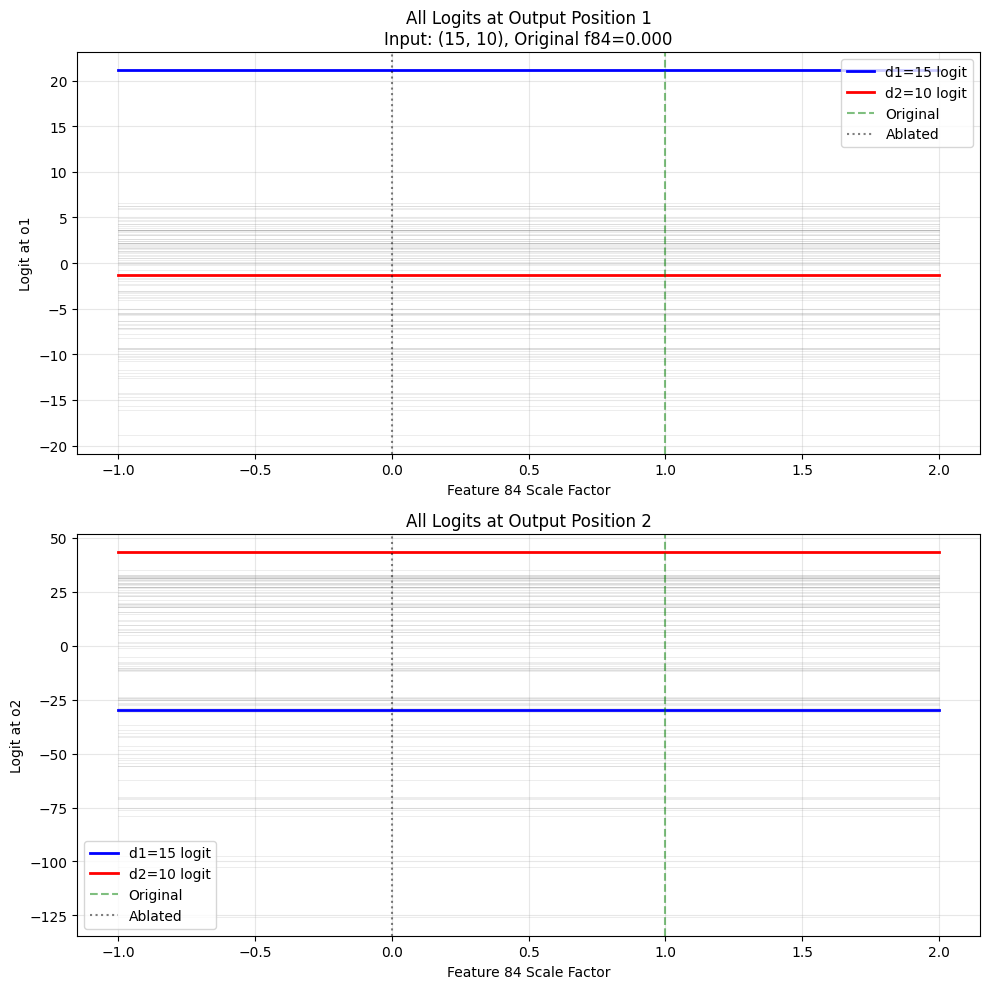


CROSSOVER ANALYSIS

Original model output: (15, 10)
Input: (15, 10)

❌ O1: No crossover detected in range [-1.0, 2.0]
   d1 logit remains higher throughout

❌ O2: No crossover detected in range [-1.0, 2.0]
   d2 logit remains higher throughout


In [ ]:
# let's focus on the logits for a particular input example (91, 83).
# plot red line for d2=83 logit, blue line for d1=91 logit, and grey lines for all other logits
# ==> should be 100 lines in total!

# Find index for example input
d1_val, d2_val = 15, 10
mask = (d1_all == d1_val) & (d2_all == d2_val)
if mask.sum() == 0:
    print(f"Input ({d1_val}, {d2_val}) not found in dataset!")
else:
    input_idx = torch.where(mask)[0][0].item()
    print(f"Found input ({d1_val}, {d2_val}) at index {input_idx}")
    
    # Get the input and original SAE activations
    inputs_i = all_ds[input_idx][0].unsqueeze(0).to(DEVICE)
    z_orig = sae_acts_all[input_idx].clone().to(DEVICE)
    feat_orig = z_orig[SPECIAL_FEAT_IDX].item()
    
    print(f"Original feature {SPECIAL_FEAT_IDX} activation: {feat_orig:.4f}")
    
    # Test scale factors from -1 to 2
    scale_factors = np.linspace(-1.0, 2.0, 30)
    
    # Storage for all logits at o1 and o2
    all_logits_o1 = []  # Will be shape [n_scales, n_digits]
    all_logits_o2 = []  # Will be shape [n_scales, n_digits]
    
    hook_name_resid = f"blocks.0.hook_resid_post"
    
    for scale in tqdm(scale_factors, desc="Testing scales"):
        z_scaled = z_orig.clone()
        z_scaled[SPECIAL_FEAT_IDX] = feat_orig * scale
        
        recon = sae.decode(z_scaled.unsqueeze(0))
        
        with torch.no_grad():
            patched_logits = model.run_with_hooks(
                inputs_i,
                fwd_hooks=[(hook_name_resid, make_sae_patch_hook(recon, act_mean, SEP_TOKEN_INDEX))]
            )
        
        # Get logits at o1 (position -2) and o2 (position -1) for ALL digits
        logits_o1 = patched_logits[0, -2, :N_DIGITS].cpu().numpy()
        logits_o2 = patched_logits[0, -1, :N_DIGITS].cpu().numpy()
        all_logits_o1.append(logits_o1)
        all_logits_o2.append(logits_o2)
    
    all_logits_o1 = np.array(all_logits_o1)  # [n_scales, n_digits]
    all_logits_o2 = np.array(all_logits_o2)  # [n_scales, n_digits]
    
    # Create 2-row plot
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))
    
    # Plot o1 logits (top row)
    ax1 = axes[0]
    
    # Plot all other logits in grey
    for digit in range(N_DIGITS):
        if digit != d1_val and digit != d2_val:
            ax1.plot(scale_factors, all_logits_o1[:, digit], 'grey', alpha=0.2, linewidth=0.5)
    
    # Plot d1 and d2 logits on top
    ax1.plot(scale_factors, all_logits_o1[:, d1_val], 'b-', linewidth=2, label=f'd1={d1_val} logit')
    ax1.plot(scale_factors, all_logits_o1[:, d2_val], 'r-', linewidth=2, label=f'd2={d2_val} logit')
    
    # Mark original activation point
    ax1.axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='Original')
    ax1.axvline(x=0.0, color='black', linestyle=':', alpha=0.5, label='Ablated')
    
    ax1.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax1.set_ylabel('Logit at o1')
    ax1.set_title(f'All Logits at Output Position 1
Input: ({d1_val}, {d2_val}), Original f{SPECIAL_FEAT_IDX}={feat_orig:.3f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot o2 logits (bottom row)
    ax2 = axes[1]
    
    # Plot all other logits in grey
    for digit in range(N_DIGITS):
        if digit != d1_val and digit != d2_val:
            ax2.plot(scale_factors, all_logits_o2[:, digit], 'grey', alpha=0.2, linewidth=0.5)
    
    # Plot d1 and d2 logits on top
    ax2.plot(scale_factors, all_logits_o2[:, d1_val], 'b-', linewidth=2, label=f'd1={d1_val} logit')
    ax2.plot(scale_factors, all_logits_o2[:, d2_val], 'r-', linewidth=2, label=f'd2={d2_val} logit')
    
    # Mark original activation point
    ax2.axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='Original')
    ax2.axvline(x=0.0, color='black', linestyle=':', alpha=0.5, label='Ablated')
    
    ax2.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax2.set_ylabel('Logit at o2')
    ax2.set_title(f'All Logits at Output Position 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax2.set_ylabel('Logit at o2')
    ax2.set_title(f'All Logits at Output Position 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if SAVE_DIR:
        plt.savefig(os.path.join(SAVE_DIR, f'all_logits_o1_o2_f{SPECIAL_FEAT_IDX}_input_{d1_val}_{d2_val}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Get original outputs (at scale=1.0)
    original_scale_idx = np.argmin(np.abs(scale_factors - 1.0))
    original_output_o1 = all_logits_o1[original_scale_idx].argmax()
    original_output_o2 = all_logits_o2[original_scale_idx].argmax()
    
    # Print crossover points for both positions
    d1_logits_o1 = all_logits_o1[:, d1_val]
    d2_logits_o1 = all_logits_o1[:, d2_val]
    diff_o1 = d1_logits_o1 - d2_logits_o1
    
    d1_logits_o2 = all_logits_o2[:, d1_val]
    d2_logits_o2 = all_logits_o2[:, d2_val]
    diff_o2 = d1_logits_o2 - d2_logits_o2
    
    print("
" + "="*60)
    print("CROSSOVER ANALYSIS")
    print("="*60)
    print(f"
Original model output: ({original_output_o1}, {original_output_o2})")
    print(f"Input: ({d1_val}, {d2_val})")
    
    # Find where sign changes (crossover) for o1
    sign_changes_o1 = np.where(np.diff(np.sign(diff_o1)))[0]
    if len(sign_changes_o1) > 0:
        crossover_idx_o1 = sign_changes_o1[0]
        crossover_scale_o1 = scale_factors[crossover_idx_o1]
        output_o1_at_crossover = all_logits_o1[crossover_idx_o1].argmax()
        output_o2_at_crossover_o1 = all_logits_o2[crossover_idx_o1].argmax()
        print(f"
📍 O1 Logits cross over at scale ≈ {crossover_scale_o1:.3f}")
        print(f"   At this point: d1 logit = {d1_logits_o1[crossover_idx_o1]:.3f}, d2 logit = {d2_logits_o1[crossover_idx_o1]:.3f}")
        print(f"   Model output: ({output_o1_at_crossover}, {output_o2_at_crossover_o1})  [original: ({original_output_o1}, {original_output_o2})]")
    else:
        print(f"
❌ O1: No crossover detected in range [{scale_factors[0]:.1f}, {scale_factors[-1]:.1f}]")
        if d1_logits_o1[0] > d2_logits_o1[0]:
            print("   d1 logit remains higher throughout")
        else:
            print("   d2 logit remains higher throughout")
    
    # Find where sign changes (crossover) for o2
    sign_changes_o2 = np.where(np.diff(np.sign(diff_o2)))[0]
    if len(sign_changes_o2) > 0:
        crossover_idx_o2 = sign_changes_o2[0]
        crossover_scale_o2 = scale_factors[crossover_idx_o2]
        output_o1_at_crossover_o2 = all_logits_o1[crossover_idx_o2].argmax()
        output_o2_at_crossover = all_logits_o2[crossover_idx_o2].argmax()
        print(f"
📍 O2 Logits cross over at scale ≈ {crossover_scale_o2:.3f}")
        print(f"   At this point: d1 logit = {d1_logits_o2[crossover_idx_o2]:.3f}, d2 logit = {d2_logits_o2[crossover_idx_o2]:.3f}")
        print(f"   Model output: ({output_o1_at_crossover_o2}, {output_o2_at_crossover})  [original: ({original_output_o1}, {original_output_o2})]")
    else:
        print(f"
❌ O2: No crossover detected in range [{scale_factors[0]:.1f}, {scale_factors[-1]:.1f}]")
        if d1_logits_o2[0] > d2_logits_o2[0]:
            print("   d1 logit remains higher throughout")
        else:
            print("   d2 logit remains higher throughout")

In [ ]:
SPECIAL_FEAT_IDX = 30

Found input (15, 10) at index 840
Original feature 30 activation: 5.2513


Testing scales: 100%|██████████| 30/30 [00:00<00:00, 150.45it/s]


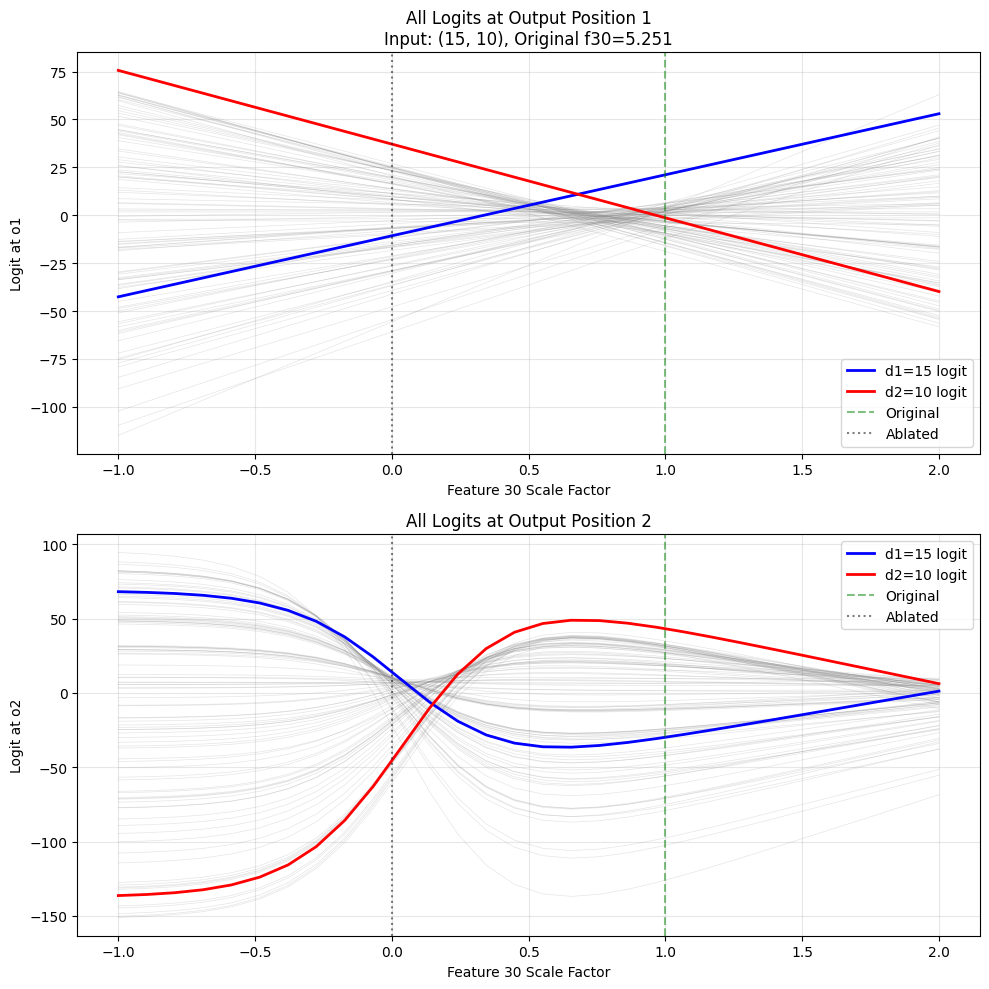


CROSSOVER ANALYSIS

Original model output: (15, 10)
Input: (15, 10)

📍 O1 Logits cross over at scale ≈ 0.655
   At this point: d1 logit = 10.133, d2 logit = 11.907
   Model output: (10, 10)  [original: (15, 10)]

📍 O2 Logits cross over at scale ≈ 0.138
   At this point: d1 logit = -6.215, d2 logit = -10.212
   Model output: (10, 48)  [original: (15, 10)]


In [ ]:
# let's focus on the logits for a particular input example (91, 83).
# plot red line for d2=83 logit, blue line for d1=91 logit, and grey lines for all other logits
# ==> should be 100 lines in total!

# Find index for example input
d1_val, d2_val = 15, 10
mask = (d1_all == d1_val) & (d2_all == d2_val)
if mask.sum() == 0:
    print(f"Input ({d1_val}, {d2_val}) not found in dataset!")
else:
    input_idx = torch.where(mask)[0][0].item()
    print(f"Found input ({d1_val}, {d2_val}) at index {input_idx}")
    
    # Get the input and original SAE activations
    inputs_i = all_ds[input_idx][0].unsqueeze(0).to(DEVICE)
    z_orig = sae_acts_all[input_idx].clone().to(DEVICE)
    feat_orig = z_orig[SPECIAL_FEAT_IDX].item()
    
    print(f"Original feature {SPECIAL_FEAT_IDX} activation: {feat_orig:.4f}")
    
    # Test scale factors from -1 to 2
    scale_factors = np.linspace(-1.0, 2.0, 30)
    
    # Storage for all logits at o1 and o2
    all_logits_o1 = []  # Will be shape [n_scales, n_digits]
    all_logits_o2 = []  # Will be shape [n_scales, n_digits]
    
    hook_name_resid = f"blocks.0.hook_resid_post"
    
    for scale in tqdm(scale_factors, desc="Testing scales"):
        z_scaled = z_orig.clone()
        z_scaled[SPECIAL_FEAT_IDX] = feat_orig * scale
        
        recon = sae.decode(z_scaled.unsqueeze(0))
        
        with torch.no_grad():
            patched_logits = model.run_with_hooks(
                inputs_i,
                fwd_hooks=[(hook_name_resid, make_sae_patch_hook(recon, act_mean, SEP_TOKEN_INDEX))]
            )
        
        # Get logits at o1 (position -2) and o2 (position -1) for ALL digits
        logits_o1 = patched_logits[0, -2, :N_DIGITS].cpu().numpy()
        logits_o2 = patched_logits[0, -1, :N_DIGITS].cpu().numpy()
        all_logits_o1.append(logits_o1)
        all_logits_o2.append(logits_o2)
    
    all_logits_o1 = np.array(all_logits_o1)  # [n_scales, n_digits]
    all_logits_o2 = np.array(all_logits_o2)  # [n_scales, n_digits]
    
    # Create 2-row plot
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))
    
    # Plot o1 logits (top row)
    ax1 = axes[0]
    
    # Plot all other logits in grey
    for digit in range(N_DIGITS):
        if digit != d1_val and digit != d2_val:
            ax1.plot(scale_factors, all_logits_o1[:, digit], 'grey', alpha=0.2, linewidth=0.5)
    
    # Plot d1 and d2 logits on top
    ax1.plot(scale_factors, all_logits_o1[:, d1_val], 'b-', linewidth=2, label=f'd1={d1_val} logit')
    ax1.plot(scale_factors, all_logits_o1[:, d2_val], 'r-', linewidth=2, label=f'd2={d2_val} logit')
    
    # Mark original activation point
    ax1.axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='Original')
    ax1.axvline(x=0.0, color='black', linestyle=':', alpha=0.5, label='Ablated')
    
    ax1.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax1.set_ylabel('Logit at o1')
    ax1.set_title(f'All Logits at Output Position 1
Input: ({d1_val}, {d2_val}), Original f{SPECIAL_FEAT_IDX}={feat_orig:.3f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot o2 logits (bottom row)
    ax2 = axes[1]
    
    # Plot all other logits in grey
    for digit in range(N_DIGITS):
        if digit != d1_val and digit != d2_val:
            ax2.plot(scale_factors, all_logits_o2[:, digit], 'grey', alpha=0.2, linewidth=0.5)
    
    # Plot d1 and d2 logits on top
    ax2.plot(scale_factors, all_logits_o2[:, d1_val], 'b-', linewidth=2, label=f'd1={d1_val} logit')
    ax2.plot(scale_factors, all_logits_o2[:, d2_val], 'r-', linewidth=2, label=f'd2={d2_val} logit')
    
    # Mark original activation point
    ax2.axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='Original')
    ax2.axvline(x=0.0, color='black', linestyle=':', alpha=0.5, label='Ablated')
    
    ax2.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax2.set_ylabel('Logit at o2')
    ax2.set_title(f'All Logits at Output Position 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlabel(f'Feature {SPECIAL_FEAT_IDX} Scale Factor')
    ax2.set_ylabel('Logit at o2')
    ax2.set_title(f'All Logits at Output Position 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if SAVE_DIR:
        plt.savefig(os.path.join(SAVE_DIR, f'all_logits_o1_o2_f{SPECIAL_FEAT_IDX}_input_{d1_val}_{d2_val}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Get original outputs (at scale=1.0)
    original_scale_idx = np.argmin(np.abs(scale_factors - 1.0))
    original_output_o1 = all_logits_o1[original_scale_idx].argmax()
    original_output_o2 = all_logits_o2[original_scale_idx].argmax()
    
    # Print crossover points for both positions
    d1_logits_o1 = all_logits_o1[:, d1_val]
    d2_logits_o1 = all_logits_o1[:, d2_val]
    diff_o1 = d1_logits_o1 - d2_logits_o1
    
    d1_logits_o2 = all_logits_o2[:, d1_val]
    d2_logits_o2 = all_logits_o2[:, d2_val]
    diff_o2 = d1_logits_o2 - d2_logits_o2
    
    print("
" + "="*60)
    print("CROSSOVER ANALYSIS")
    print("="*60)
    print(f"
Original model output: ({original_output_o1}, {original_output_o2})")
    print(f"Input: ({d1_val}, {d2_val})")
    
    # Find where sign changes (crossover) for o1
    sign_changes_o1 = np.where(np.diff(np.sign(diff_o1)))[0]
    if len(sign_changes_o1) > 0:
        crossover_idx_o1 = sign_changes_o1[0]
        crossover_scale_o1 = scale_factors[crossover_idx_o1]
        output_o1_at_crossover = all_logits_o1[crossover_idx_o1].argmax()
        output_o2_at_crossover_o1 = all_logits_o2[crossover_idx_o1].argmax()
        print(f"
📍 O1 Logits cross over at scale ≈ {crossover_scale_o1:.3f}")
        print(f"   At this point: d1 logit = {d1_logits_o1[crossover_idx_o1]:.3f}, d2 logit = {d2_logits_o1[crossover_idx_o1]:.3f}")
        print(f"   Model output: ({output_o1_at_crossover}, {output_o2_at_crossover_o1})  [original: ({original_output_o1}, {original_output_o2})]")
    else:
        print(f"
❌ O1: No crossover detected in range [{scale_factors[0]:.1f}, {scale_factors[-1]:.1f}]")
        if d1_logits_o1[0] > d2_logits_o1[0]:
            print("   d1 logit remains higher throughout")
        else:
            print("   d2 logit remains higher throughout")
    
    # Find where sign changes (crossover) for o2
    sign_changes_o2 = np.where(np.diff(np.sign(diff_o2)))[0]
    if len(sign_changes_o2) > 0:
        crossover_idx_o2 = sign_changes_o2[0]
        crossover_scale_o2 = scale_factors[crossover_idx_o2]
        output_o1_at_crossover_o2 = all_logits_o1[crossover_idx_o2].argmax()
        output_o2_at_crossover = all_logits_o2[crossover_idx_o2].argmax()
        print(f"
📍 O2 Logits cross over at scale ≈ {crossover_scale_o2:.3f}")
        print(f"   At this point: d1 logit = {d1_logits_o2[crossover_idx_o2]:.3f}, d2 logit = {d2_logits_o2[crossover_idx_o2]:.3f}")
        print(f"   Model output: ({output_o1_at_crossover_o2}, {output_o2_at_crossover})  [original: ({original_output_o1}, {original_output_o2})]")
    else:
        print(f"
❌ O2: No crossover detected in range [{scale_factors[0]:.1f}, {scale_factors[-1]:.1f}]")
        if d1_logits_o2[0] > d2_logits_o2[0]:
            print("   d1 logit remains higher throughout")
        else:
            print("   d2 logit remains higher throughout")